In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import glob

print("All imports working ✅")
print("Waiting for HAM10000 download to finish...")


All imports working ✅
Waiting for HAM10000 download to finish...


In [2]:
import pandas as pd

df = pd.read_csv("../data/HAM10000_metadata.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10015, 7)

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print("Columns:", df.columns.tolist())
print("\nUnique diagnosis labels:")
print(df['dx'].value_counts())
print("\nWhat each label means:")
label_meanings = {
    'nv': 'Melanocytic nevi (moles) — benign',
    'mel': 'Melanoma — malignant, dangerous',
    'bkl': 'Benign keratosis — benign',
    'bcc': 'Basal cell carcinoma — malignant',
    'akiec': 'Actinic keratoses — pre-cancerous',
    'vasc': 'Vascular lesions — benign',
    'df': 'Dermatofibroma — benign'
}
for k, v in label_meanings.items():
    print(f"  {k}: {v}")

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Unique diagnosis labels:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

What each label means:
  nv: Melanocytic nevi (moles) — benign
  mel: Melanoma — malignant, dangerous
  bkl: Benign keratosis — benign
  bcc: Basal cell carcinoma — malignant
  akiec: Actinic keratoses — pre-cancerous
  vasc: Vascular lesions — benign
  df: Dermatofibroma — benign


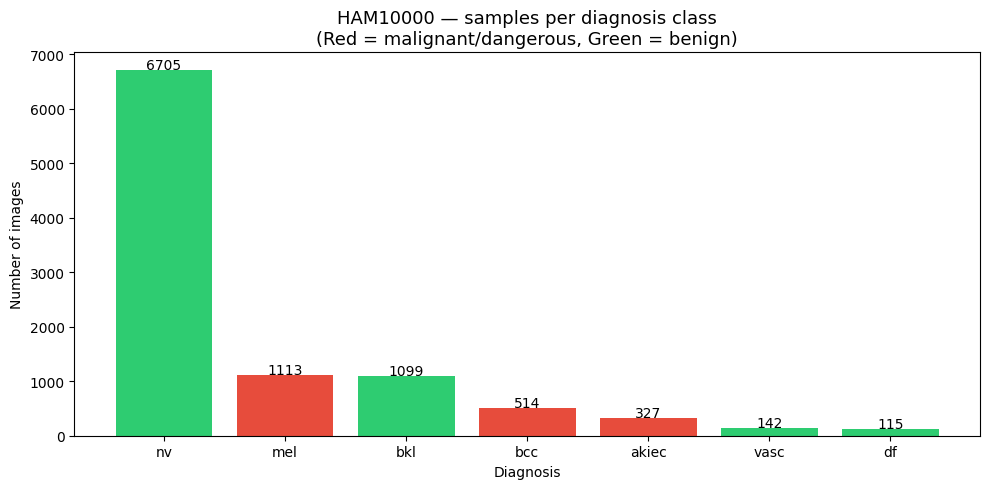


⚠️ Notice: 'nv' (moles) dominates the dataset — class imbalance!
We'll handle this on Day 2 with class weights


In [4]:
import matplotlib.pyplot as plt

counts = df['dx'].value_counts()
colors = ['#e74c3c' if l in ['mel','bcc','akiec'] else '#2ecc71' 
          for l in counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color=colors)
plt.title('HAM10000 — samples per diagnosis class\n(Red = malignant/dangerous, Green = benign)', 
          fontsize=13)
plt.xlabel('Diagnosis')
plt.ylabel('Number of images')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\n⚠️ Notice: 'nv' (moles) dominates the dataset — class imbalance!")
print("We'll handle this on Day 2 with class weights")

In [5]:
import os
import glob

# Find all image files
part1 = glob.glob("../data/HAM10000_images_part_1/*.jpg")
part2 = glob.glob("../data/HAM10000_images_part_2/*.jpg")
all_images = part1 + part2

print(f"Images in part 1: {len(part1)}")
print(f"Images in part 2: {len(part2)}")
print(f"Total images: {len(all_images)}")
print(f"Total rows in CSV: {len(df)}")

Images in part 1: 5000
Images in part 2: 5015
Total images: 10015
Total rows in CSV: 10015


In [6]:
# Build a dictionary: image_id -> full path
image_paths = {}
for path in all_images:
    image_id = os.path.splitext(os.path.basename(path))[0]
    image_paths[image_id] = path

# Add path column to dataframe
df['image_path'] = df['image_id'].map(image_paths)

# Check for missing images
missing = df['image_path'].isna().sum()
print(f"Images matched: {len(df) - missing} / {len(df)}")
print(f"Missing: {missing}")

df.head(3)

Images matched: 10015 / 10015
Missing: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1\ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1\ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1\ISIC_0026769.jpg


C:\Users\karth\AppData\Local\Temp\ipykernel_12720\2729410044.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df.groupby('dx').apply(lambda x: x.sample(min(3, len(x)))).reset_index(drop=True)


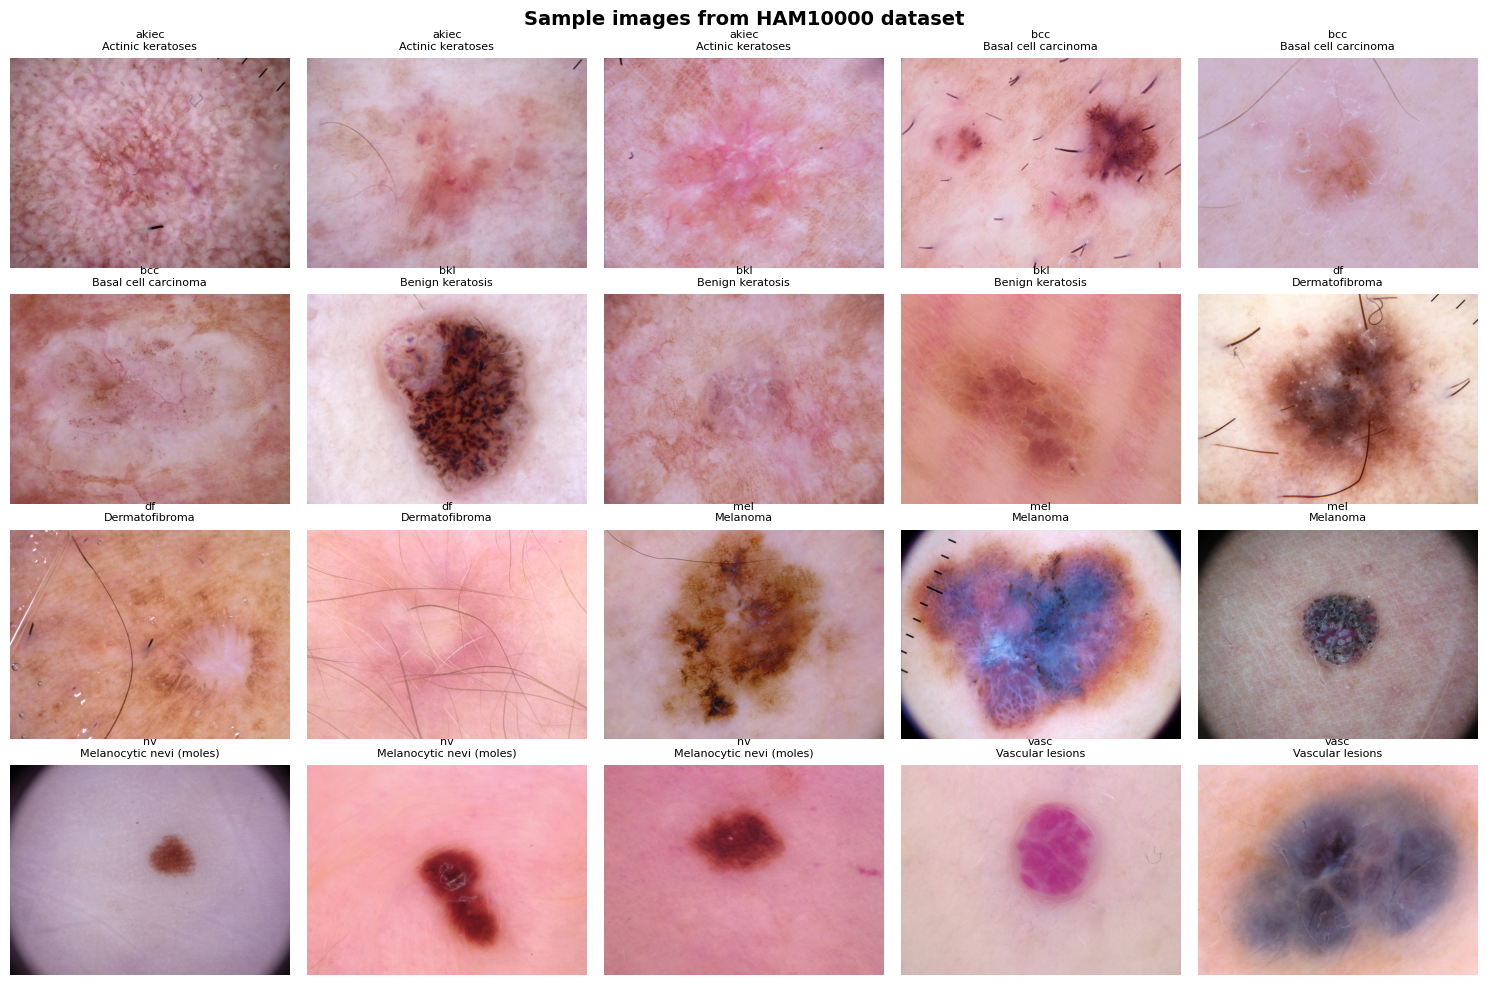

In [7]:
from PIL import Image
import numpy as np

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()

# Show 2-3 images from each class
samples = df.groupby('dx').apply(lambda x: x.sample(min(3, len(x)))).reset_index(drop=True)
samples = samples.head(20)

for i, (_, row) in enumerate(samples.iterrows()):
    if i >= 20:
        break
    img = Image.open(row['image_path'])
    axes[i].imshow(img)
    axes[i].set_title(f"{row['dx']}\n{label_meanings[row['dx']].split('—')[0].strip()}", 
                      fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample images from HAM10000 dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # Map string labels to numbers
        self.label_map = {
            'nv': 0, 'mel': 1, 'bkl': 2, 
            'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6
        }

    def __len__(self):
        # How many images in total
        return len(self.df)

    def __getitem__(self, idx):
        # Get one row from the dataframe
        row = self.df.iloc[idx]
        
        # Load image
        image = Image.open(row['image_path']).convert('RGB')
        
        # Apply transforms if any
        if self.transform:
            image = self.transform(image)
        
        # Get numeric label
        label = self.label_map[row['dx']]
        
        return image, label


# Test it works
basic_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = HAMDataset(df, transform=basic_transform)
img, lbl = dataset[0]
label_names = {v: k for k, v in dataset.label_map.items()}

print("Image tensor shape:", img.shape)   # should be [3, 64, 64]
print("Label number:", lbl)
print("Label name:", label_names[lbl])
print("Total dataset size:", len(dataset))
print("\n✅ HAMDataset class works correctly")

Image tensor shape: torch.Size([3, 64, 64])
Label number: 2
Label name: bkl
Total dataset size: 10015

✅ HAMDataset class works correctly
